# Demo notebook for roughness estimation

### Imports

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt
import numpy as np
import torch

from src.constants import CKPT_FOLDER
from src.generate import generate_Z, create_data, load_data
from src.models import CNN
from src.utils import split_and_load_data

from tools.train import train
from tools.test import draw_predictions

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device '+str(device))

Using device cuda


### Data visualization

We simulate a stochastic process driven by a Hurst parameter $H \in (0, 1)$. It is defined by the following integral with respect to a standard Brownian motion $W_u$:
$$Z_t = \eta \sqrt{2H }\int_0^t (t-u)^{H-\frac{1}{2}} dW_u$$

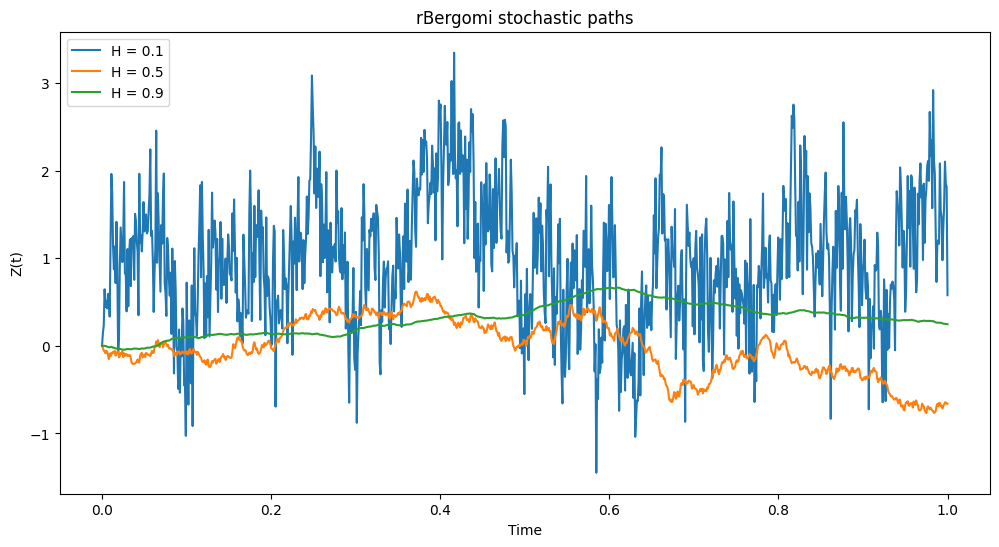

In [4]:
n_points = 1000
eta = 1
T = 1
time = np.linspace(0, 1, n_points)

plt.figure(figsize=(12,6))
for h in [0.1, 0.5, 0.9]:
    plt.plot(time, generate_Z(h, eta, 1, n_points, T)[0], label=f"H = {h}")
plt.title("rBergomi stochastic paths")
plt.xlabel("Time")
plt.ylabel("Z(t)")
plt.legend()
plt.show()

For $H < 0.5$, the increments of $Z$ are negatively correlated, and for $H > 0.5$, they are positively correlated. Increments are independant when $H=0.5$.

In [5]:
n_samples = 40000
n_H = 2000
create_data(n_samples, n_points, T, n_H)
Z, H = load_data(n_samples, n_points)

100%|██████████| 2000/2000 [15:39<00:00,  2.13it/s]


Saving data...
Loading data...


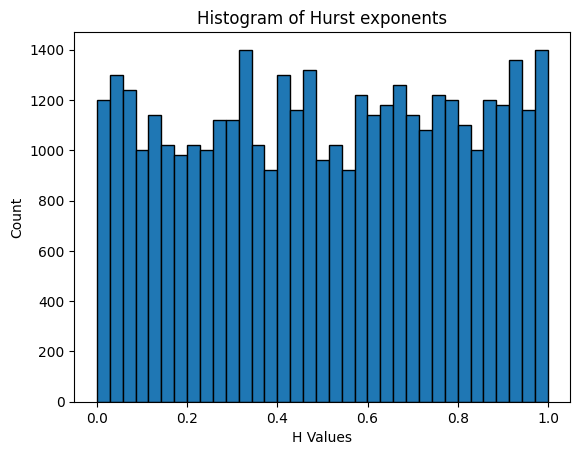

In [12]:
plt.hist(H, bins='auto', edgecolor='black')
plt.xlabel('H Values')
plt.ylabel('Count')
plt.title('Histogram of Hurst exponents')
plt.show()

In [7]:
batch_size = 512
train_loader, val_loader, test_loader = split_and_load_data(Z, H, batch_size=batch_size)

### CNN prediction

In [8]:
cnn = CNN(n_points).to(device=device)
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

In [9]:
ckpt_prefix = "cnn_"
n_epochs = 60
train_losses, val_losses = train(cnn, train_loader, n_epochs, optimizer, criterion, val_loader=val_loader, ckpt_prefix=ckpt_prefix, device=device)

Model saved !
Epoch: 1 | Losses: {train_loss: 0.05687, val_loss: 0.07587}
Epoch: 2 | Losses: {train_loss: 0.01517, val_loss: 0.11697}
Model saved !
Epoch: 3 | Losses: {train_loss: 0.01100, val_loss: 0.05694}
Model saved !
Epoch: 4 | Losses: {train_loss: 0.00848, val_loss: 0.05060}
Model saved !
Epoch: 5 | Losses: {train_loss: 0.00739, val_loss: 0.04753}
Model saved !
Epoch: 6 | Losses: {train_loss: 0.00693, val_loss: 0.03229}
Epoch: 7 | Losses: {train_loss: 0.00608, val_loss: 0.03796}
Model saved !
Epoch: 8 | Losses: {train_loss: 0.00610, val_loss: 0.02294}
Model saved !
Epoch: 9 | Losses: {train_loss: 0.00627, val_loss: 0.02153}
Model saved !
Epoch: 10 | Losses: {train_loss: 0.00498, val_loss: 0.01830}
Epoch: 11 | Losses: {train_loss: 0.00434, val_loss: 0.01968}
Model saved !
Epoch: 12 | Losses: {train_loss: 0.00475, val_loss: 0.01724}
Model saved !
Epoch: 13 | Losses: {train_loss: 0.00412, val_loss: 0.01604}
Model saved !
Epoch: 14 | Losses: {train_loss: 0.00431, val_loss: 0.01487}
E

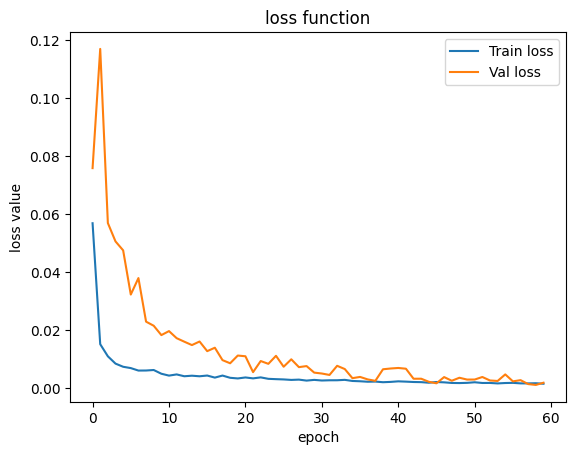

In [10]:
plt.plot(range(n_epochs), train_losses, label="Train loss")
plt.plot(range(n_epochs), val_losses, label="Val loss")
plt.legend()
plt.title('loss function')
plt.xlabel('epoch')
plt.ylabel('loss value')
plt.show()

Generating paths ...


100%|██████████| 11/11 [00:05<00:00,  1.99it/s]


Predicting with model 1 (CNN)...


100%|██████████| 11/11 [00:00<00:00, 32.24it/s]


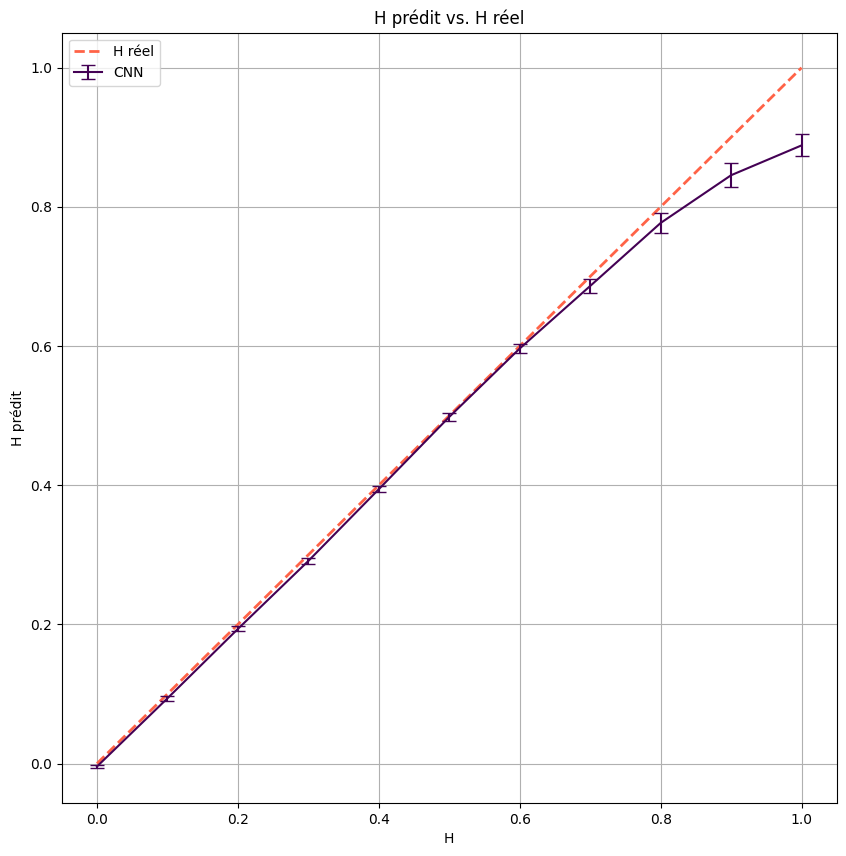

In [11]:
cnn.load_state_dict(torch.load(os.path.join(CKPT_FOLDER, ckpt_prefix + "best_model.pt"), weights_only=True, map_location=device))
draw_predictions(models=[cnn], model_labels=["CNN"], paths_per_H=1000, n_points=n_points, T=T, device=device)